# Adım 1

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Veri okuma
df = pd.read_csv('/Users/nurefsandolas/Projects/predictive_maintenance_project/data/predictive_maintenance.csv')

# Verinin ilk 5 satırı
print(df.head())

# Verinin genel yapısı (sütun tipleri ve eksik değer kontrolü)
df.info()

  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    M            298.1                308.6              1551    42.8   
1    L            298.2                308.7              1408    46.3   
2    L            298.1                308.5              1498    49.4   
3    L            298.2                308.6              1433    39.5   
4    L            298.2                308.7              1408    40.0   

   Tool wear  Machine failure  TWF  HDF  PWF  OSF  RNF  
0          0                0    0    0    0    0    0  
1          3                0    0    0    0    0    0  
2          5                0    0    0    0    0    0  
3          7                0    0    0    0    0    0  
4          9                0    0    0    0    0    0  
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Type       

--- Arıza Dağılımı ---
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


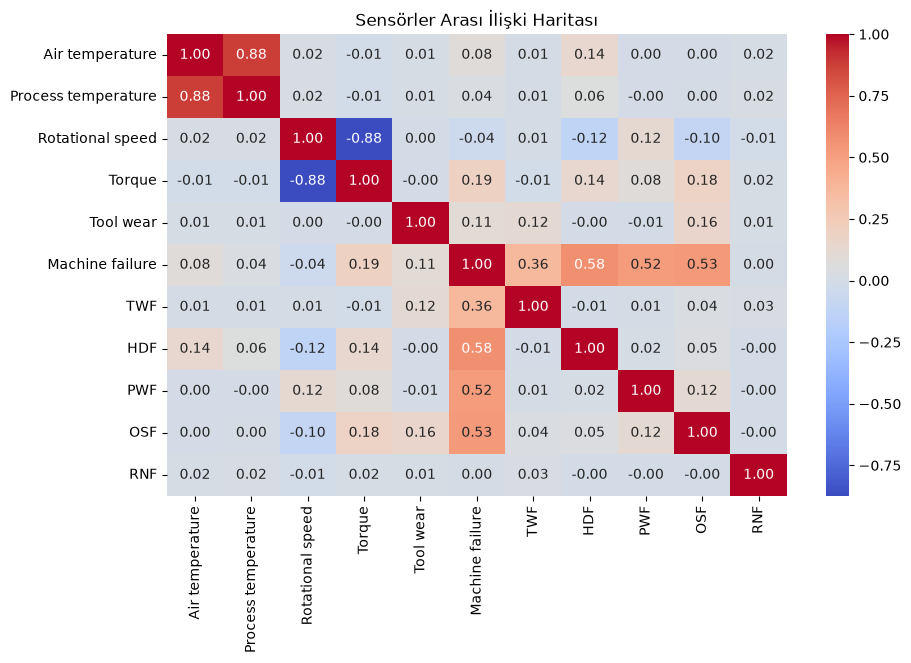

In [ ]:
# 1. Hata (Failure) oranlarını kontrol
print("--- Arıza Dağılımı ---")
print(df['Machine failure'].value_counts(normalize=True))

# 2. Korelasyon Matrisi (Hangi sensörler birbirini tetikliyor?)
# 'Type' sütunu kategorik olduğu için onu şimdilik hariç tutuyoruz
plt.figure(figsize=(10, 6))
sns.heatmap(df.drop(columns=['Type']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Sensörler Arası İlişki Haritası")
plt.show()

In [ ]:
# Yeni feature oluşturma
df['temp_diff'] = df['Process temperature'] - df['Air temperature']
df['power'] = df['Torque'] * df['Rotational speed']
df['wear_x_torque'] = df['Tool wear'] * df['Torque']

# Yeni değişkenlerin Machine failure ile korelasyonu
print(df[['Machine failure', 'temp_diff', 'power', 'wear_x_torque']].corr())

                 Machine failure  temp_diff     power  wear_x_torque
Machine failure         1.000000  -0.111676  0.176039       0.190427
temp_diff              -0.111676   1.000000  0.006694      -0.005051
power                   0.176039   0.006694  1.000000       0.368842
wear_x_torque           0.190427  -0.005051  0.368842       1.000000


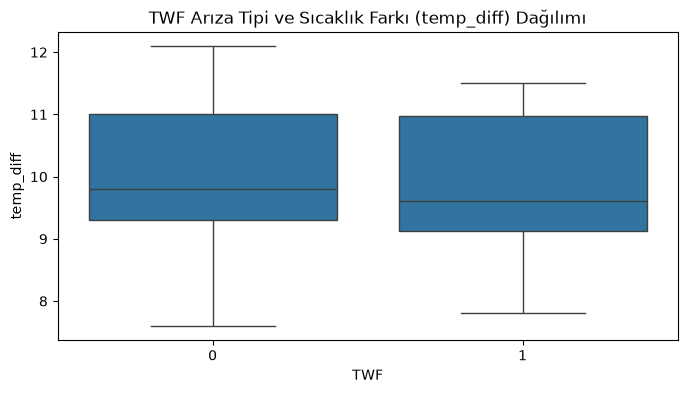

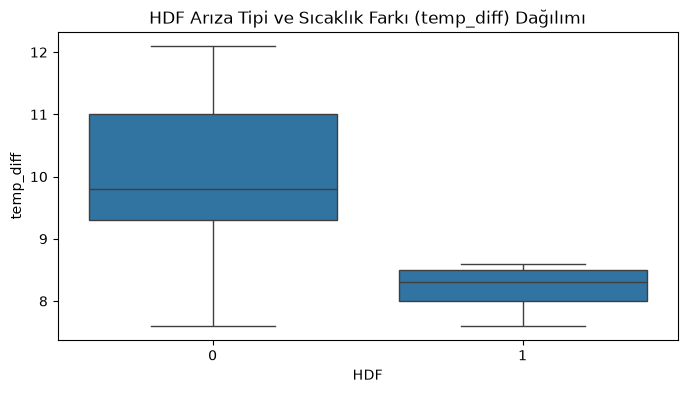

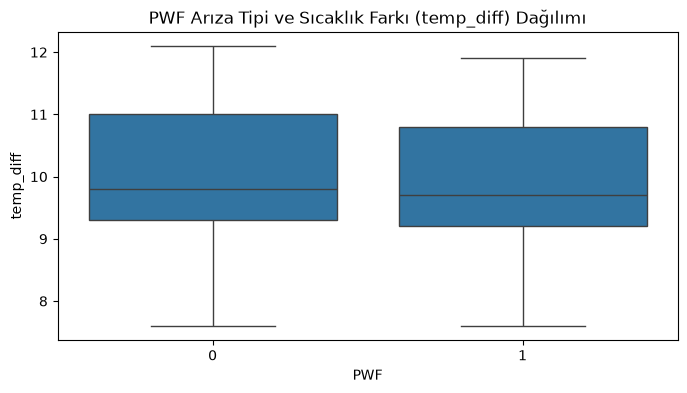

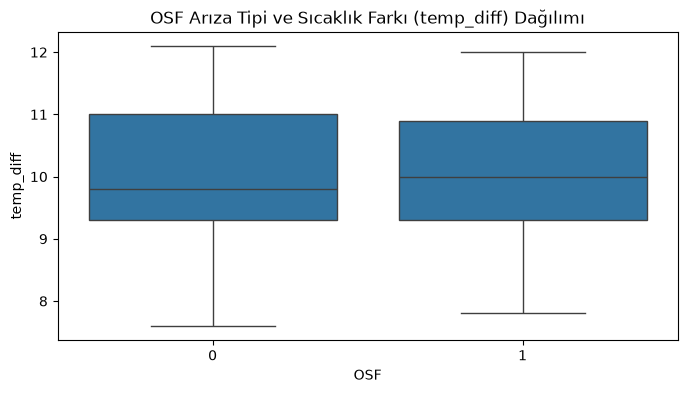

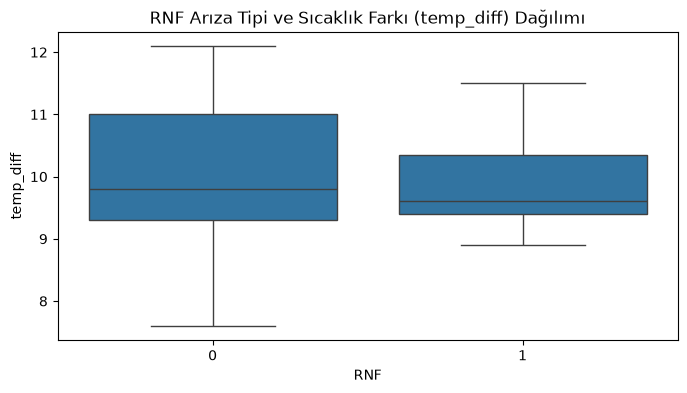

In [ ]:
# Hangi failure tiplerinin arıza ile en çok ilişkili olduğunu görselleştirme
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

for col in failure_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col], y=df['temp_diff'])
    plt.title(f"{col} Arıza Tipi ve Sıcaklık Farkı (temp_diff) Dağılımı")
    plt.show()

# Adım 2

In [10]:
print(df.columns.tolist())

['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'temp_diff', 'power', 'wear_x_torque']


In [11]:
# Target (tahmin edeceğimiz değişken)
y = df["Machine failure"]

# Feature'lar (modele verilecek bilgiler)
X = df.drop(
    columns=[
        "Machine failure",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)

X.head()

X boyutu: (10000, 9)
y boyutu: (10000,)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque
0,M,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0


In [12]:
# Type sütununu One-Hot Encoding ile sayısallaştır
X = pd.get_dummies(X, columns=["Type"], dtype=int)

print("Yeni X boyutu:", X.shape)
X.head()

Yeni X boyutu: (10000, 11)


,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,temp_diff,power,wear_x_torque,Type_H,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,10.5,66382.8,0.0,0,0,1
1,298.2,308.7,1408,46.3,3,10.5,65190.4,138.9,0,1,0
2,298.1,308.5,1498,49.4,5,10.4,74001.2,247.0,0,1,0
3,298.2,308.6,1433,39.5,7,10.4,56603.5,276.5,0,1,0
4,298.2,308.7,1408,40.0,9,10.5,56320.0,360.0,0,1,0


In [13]:
from sklearn.model_selection import train_test_split

# Adım 3

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (8000, 11)
Test: (2000, 11)


In [15]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTrain dağılımı:")
print(y_train.value_counts())

print("\nTest dağılımı:")
print(y_test.value_counts())

X_train: (8000, 11)
X_test : (2000, 11)
y_train: (8000,)
y_test : (2000,)

Train dağılımı:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Test dağılımı:
Machine failure
0    1932
1      68
Name: count, dtype: int64


# Adım 4

In [16]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    random_state=42
)

model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
# Test verisi üzerinde tahmin yap
y_pred = model.predict(X_test)

# İlk 10 tahmin
print("İlk 10 tahmin:")
print(y_pred[:10])

print("\nİlk 10 gerçek değer:")
print(y_test.iloc[:10].values)

İlk 10 tahmin:
[0 0 0 0 0 0 0 0 0 0]

İlk 10 gerçek değer:
[0 0 0 0 0 0 0 0 0 0]
